# ***Mid-Price Movement Forecasting in High-Frequency Limit Order Book Data: A Deep Learning Pipeline for Amazon NASDAQ***

In [ ]:
!pip install hdf5storage

In [ ]:
# Standard library
import os
import warnings
import datetime
import itertools

# Third-party: data & math
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

# Third-party: machine learning
import hdf5storage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Third-party: deep learning (PyTorch)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Third-party: deep learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.layers import (
    Conv1D,
    Dense,
    Dropout,
    Flatten,
    LSTM,
    MaxPooling1D,
)
from tensorflow.keras.models import Sequential

# Third-party: visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Google Colab
from google.colab import drive

warnings.filterwarnings("ignore")

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Reading Functions

In [ ]:
def load_lob_dataset(file_path: str) -> pd.DataFrame:
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Dataset file not found: {file_path}")
    try:
        data = hdf5storage.loadmat(file_path)
    except Exception as e:
        raise RuntimeError(f"Error reading .mat file: {e}")

    if "LOB" not in data:
        raise ValueError("Key 'LOB' not found inside .mat file")

    df = pd.DataFrame(data["LOB"])

    if df.empty:
        raise ValueError("Loaded dataset is empty")

    return df


def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    return df

def print_dataset_info(df: pd.DataFrame):

    print("\nDataset loaded successfully")
    print("Shape:", df.shape)

    print("\nFirst rows:")
    print(df.head())

    print("\nColumns:")
    print(df.columns)

# Feature Engineering Functions

Creating features:

In [ ]:
def create_features(df):
    df = df.copy()
    eps = 1e-9

    # ------------------------------------------------------------------
    # BASIC REFERENCES
    # ------------------------------------------------------------------
    df["mid_price"] = df["Mid_Price"]
    df["spread"] = df["Spread"]
    df["relative_spread"] = df["spread"] / (df["mid_price"] + eps)

    bid_price_cols = [f"BidPrice{i}" for i in range(1, 11)]
    ask_price_cols = [f"AskPrice{i}" for i in range(1, 11)]
    bid_vol_cols = [f"BidVolume{i}" for i in range(1, 11)]
    ask_vol_cols = [f"AskVolume{i}" for i in range(1, 11)]

    # ------------------------------------------------------------------
    # DEPTH AGGREGATES
    # ------------------------------------------------------------------
    df["total_bid_depth"] = df[bid_vol_cols].sum(axis=1)
    df["total_ask_depth"] = df[ask_vol_cols].sum(axis=1)

    df["depth_imbalance_10"] = (
        (df["total_bid_depth"] - df["total_ask_depth"]) /
        (df["total_bid_depth"] + df["total_ask_depth"] + eps)
    )

    df["imbalance_level1"] = (
        (df["BidVolume1"] - df["AskVolume1"]) /
        (df["BidVolume1"] + df["AskVolume1"] + eps)
    )

    for k in [2, 5, 10]:
        bid_sum_k = df[[f"BidVolume{i}" for i in range(1, k + 1)]].sum(axis=1)
        ask_sum_k = df[[f"AskVolume{i}" for i in range(1, k + 1)]].sum(axis=1)

        df[f"cum_bid_depth_{k}"] = bid_sum_k
        df[f"cum_ask_depth_{k}"] = ask_sum_k

        df[f"depth_imbalance_{k}"] = (
            (bid_sum_k - ask_sum_k) / (bid_sum_k + ask_sum_k + eps)
        )

    df["top2_bid_depth_share"] = (
        (df["BidVolume1"] + df["BidVolume2"]) / (df["total_bid_depth"] + eps)
    )
    df["top2_ask_depth_share"] = (
        (df["AskVolume1"] + df["AskVolume2"]) / (df["total_ask_depth"] + eps)
    )

    # ------------------------------------------------------------------
    # MICROPRICE FEATURES (THE BEST SIGNAL IN MY PIPELINE(SEE M.I. Section))
    # ------------------------------------------------------------------
    df["microprice"] = (
        df["AskPrice1"] * df["BidVolume1"] +
        df["BidPrice1"] * df["AskVolume1"]
    ) / (df["BidVolume1"] + df["AskVolume1"] + eps)

    df["microprice_minus_mid"] = df["microprice"] - df["mid_price"]
    df["microprice_rel"] = df["microprice_minus_mid"] / (df["spread"] + eps)
    df["microprice_change_1"] = df["microprice"].diff()

    # ------------------------------------------------------------------
    # MID-PRICE DYNAMICS
    # ------------------------------------------------------------------
    df["mid_price_change_1"] = df["mid_price"].diff()
    df["mid_price_return_1"] = df["mid_price"].pct_change()

    # ------------------------------------------------------------------
    # STATIONARY PRICE-DISTANCE FEATURES
    # ------------------------------------------------------------------
    for i in range(1, 11):
        df[f"ask_dist_mid_{i}"] = (
            df[f"AskPrice{i}"] - df["mid_price"]
        ) / (df["mid_price"] + eps)

        df[f"bid_dist_mid_{i}"] = (
            df[f"BidPrice{i}"] - df["mid_price"]
        ) / (df["mid_price"] + eps)

    # ------------------------------------------------------------------
    # PRICE GAP / BOOK SHAPE FEATURES
    # ------------------------------------------------------------------
    for i in range(1, 10):
        df[f"ask_gap_{i}_{i+1}"] = df[f"AskPrice{i+1}"] - df[f"AskPrice{i}"]
        df[f"bid_gap_{i}_{i+1}"] = df[f"BidPrice{i}"] - df[f"BidPrice{i+1}"]

    df["ask_slope_top5"] = (
        (df["AskPrice5"] - df["AskPrice1"]) /
        (df[[f"AskVolume{i}" for i in range(1, 6)]].sum(axis=1) + eps)
    )

    df["bid_slope_top5"] = (
        (df["BidPrice1"] - df["BidPrice5"]) /
        (df[[f"BidVolume{i}" for i in range(1, 6)]].sum(axis=1) + eps)
    )

    df["slope_diff_top5"] = df["bid_slope_top5"] - df["ask_slope_top5"]

    # ------------------------------------------------------------------
    # QUEUE DYNAMICS / OFI FEATURES (HELPED ME TO INCREASE THE F1 OF DOWN LABEL PREDICTION)
    # ------------------------------------------------------------------
    for i in range(1, 6):
        df[f"delta_bid_vol{i}"] = df[f"BidVolume{i}"].diff()
        df[f"delta_ask_vol{i}"] = df[f"AskVolume{i}"].diff()
        df[f"ofi_l{i}"] = df[f"delta_bid_vol{i}"] - df[f"delta_ask_vol{i}"]

    df["delta_bid_price1"] = df["BidPrice1"].diff()
    df["delta_ask_price1"] = df["AskPrice1"].diff()

    df["ofi_l1_simple"] = df["delta_bid_vol1"] - df["delta_ask_vol1"]

    df["queue_pressure_l1"] = (
        (df["delta_bid_vol1"] - df["delta_ask_vol1"]) /
        (df["BidVolume1"] + df["AskVolume1"] + eps)
    )

    df["ofi_sum_3"] = df["ofi_l1"] + df["ofi_l2"] + df["ofi_l3"]
    df["ofi_sum_5"] = df["ofi_l1"] + df["ofi_l2"] + df["ofi_l3"] + df["ofi_l4"] + df["ofi_l5"]

    # ------------------------------------------------------------------
    # CLASS-0 (DOWN) HELPER FEATURES
    # ------------------------------------------------------------------
    df["bid_depletion_top3"] = -(
        df["delta_bid_vol1"] + df["delta_bid_vol2"] + df["delta_bid_vol3"]
    )

    df["ask_build_top3"] = (
        df["delta_ask_vol1"] + df["delta_ask_vol2"] + df["delta_ask_vol3"]
    )

    df["sell_pressure_asym_top3"] = df["ask_build_top3"] + df["bid_depletion_top3"]

    df["microprice_rel_roll_mean_3"] = df["microprice_rel"].rolling(3).mean()
    df["microprice_rel_roll_sum_5"] = df["microprice_rel"].rolling(5).sum()
    df["microprice_neg_pressure_5"] = (df["microprice_rel"] < 0).rolling(5).sum()

    # ------------------------------------------------------------------
    # ROLLING FEATURES
    # ------------------------------------------------------------------
    for w in [5, 10]:
        df[f"imbalance_level1_roll_mean_{w}"] = df["imbalance_level1"].rolling(w).mean()
        df[f"depth_imbalance_10_roll_mean_{w}"] = df["depth_imbalance_10"].rolling(w).mean()
        df[f"microprice_rel_roll_mean_{w}"] = df["microprice_rel"].rolling(w).mean()
        df[f"ofi_l1_simple_roll_mean_{w}"] = df["ofi_l1_simple"].rolling(w).mean()
        df[f"spread_roll_std_{w}"] = df["spread"].rolling(w).std()
        df[f"mid_price_change_roll_std_{w}"] = df["mid_price_change_1"].rolling(w).std()

    df["spread_roll_mean_5"] = df["spread"].rolling(window=5).mean()
    df["imbalance_roll_mean_5"] = df["imbalance_level1"].rolling(window=5).mean()

    # ------------------------------------------------------------------
    # TIME FEATURES (THEY ARE AUTOMATICALLY DROPPED LATER SINCE THIS IS A SINGLE DAY DATA)
    # ------------------------------------------------------------------
    if "Time" in df.columns:
        try:
            df["Time"] = pd.to_datetime(df["Time"])
            df["hour"] = df["Time"].dt.hour
            df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
            df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
        except Exception:
            pass

    # ------------------------------------------------------------------
    # CLEANUP
    # ------------------------------------------------------------------
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    return df

Creating Labels (important!):

I set threshold=0.0001 for a change to count non-stationary because of the previous work of Ntakaris and it also gave me a better distribution of labels thus a better balance in data

In [ ]:
def create_labels(df, k=10, threshold=0.0001):
    """
    LABELS
    ------
    0 = Down
    1 = Stationary
    2 = Up
    """

    df = df.copy()

    # Future mid-price k events ahead.
    df["future_mid_price"] = df["mid_price"].shift(-k)

    # Absolute future change relative to current mid-price.
    df["price_change"] = df["future_mid_price"] - df["mid_price"]

    # Optional relative change can also be useful for analysis.
    df["price_change_rel"] = df["price_change"] / (df["mid_price"] + 1e-9)

    def classify(x):
        if x > threshold:
            return 2   # Up
        elif x < -threshold:
            return 0   # Down
        else:
            return 1   # Stationary

    df["label"] = df["price_change"].apply(classify)

    # Last k rows cannot be labeled because future price is missing.
    df.dropna(inplace=True)

    return df

In [ ]:
def get_feature_columns(df):

    #Excluding these columns to not to cause leakage

    exclude_cols = [
        "Time",
        "Mid_Price",
        "Spread",
        "mid_price",
        "future_mid_price",
        "price_change",
        "price_change_rel",
        "label",
    ]

    feature_cols = [c for c in df.columns if c not in exclude_cols]
    return feature_cols

Removing features to reduce noise and overfitting, by performing removing constant features, correlation analysis and mutual information filter:

In [ ]:
def select_features_train_only(
    X_train,
    y_train,
    X_val=None,
    corr_threshold=0.95,
    mi_top_k=60
):
    X_train = X_train.copy()
    X_val = X_val.copy() if X_val is not None else None

    selection_report = {}

    # --------------------------------------------------------------
    # 1. REMOVING CONSTANT / NEAR-CONSTANT COLUMNS
    # --------------------------------------------------------------
    nunique = X_train.nunique()
    constant_cols = nunique[nunique <= 1].index.tolist()

    X_train.drop(columns=constant_cols, inplace=True, errors="ignore")
    if X_val is not None:
        X_val.drop(columns=constant_cols, inplace=True, errors="ignore")

    selection_report["constant_cols_removed"] = constant_cols

    # --------------------------------------------------------------
    # 2. REMOVING HIGHLY CORRELATED FEATURES
    # --------------------------------------------------------------
    corr_matrix = X_train.corr().abs()

    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop_corr = [col for col in upper.columns if any(upper[col] > corr_threshold)]

    X_train.drop(columns=to_drop_corr, inplace=True, errors="ignore")
    if X_val is not None:
        X_val.drop(columns=to_drop_corr, inplace=True, errors="ignore")

    selection_report["corr_cols_removed"] = to_drop_corr

    # --------------------------------------------------------------
    # 3. MUTUAL INFORMATION FILTER
    # --------------------------------------------------------------

    mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
    mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

    k = min(mi_top_k, len(mi_series))
    selected_columns = mi_series.head(k).index.tolist()

    X_train_sel = X_train[selected_columns].copy()
    X_val_sel = X_val[selected_columns].copy() if X_val is not None else None

    selection_report["mi_scores"] = mi_series
    selection_report["selected_columns"] = selected_columns

    return X_train_sel, X_val_sel, selected_columns, selection_report

# Logistic Regression Functions

In [ ]:
# ------------------------------------------------------------
# LOGISTIC REGRESSION EVALUATION
# ------------------------------------------------------------
def evaluate_model(model_name, y_true, y_pred):
    """
    Evaluate a classification model and return key metrics.
    """

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"\n{'=' * 50}")
    print(f"{model_name}")
    print(f"{'=' * 50}")
    print(f"Accuracy   : {accuracy:.4f}")
    print(f"Macro F1   : {macro_f1:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    return {
        "model": model_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

# MLP Functions

MLP training:

In [ ]:
# ------------------------------------------------------------
# MLP TRAINING FUNCTION
# ------------------------------------------------------------
def train_mlp_torch(
    model,
    train_loader,
    val_loader,
    device,
    y_train_array,
    criterion=None,
    lr=0.001,
    weight_decay=1e-4,
    max_epochs=120,
    patience=15
):
    if criterion is None:
        class_counts = np.bincount(np.asarray(y_train_array))
        class_weights = class_counts.sum() / (len(class_counts) * class_counts)
        class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

    # AdamW (better weight decay)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    # LR Scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",      # F1 maximize ediyoruz
        factor=0.5,      # lr * 0.5
        patience=5,      # 5 epoch iyileşme olmazsa tetikle
    )

    model.to(device)

    best_val_f1 = -np.inf
    best_state = None
    epochs_without_improvement = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_macro_f1": [],
        "lr": []
    }

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        total_train = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            total_train += X_batch.size(0)

        train_loss = running_loss / total_train

        val_loss, val_acc, val_macro_f1, _, _ = evaluate_model(model, val_loader, device)

        # SETTING THE SCHEDULER ACCORDING TO MACRO_F1
        scheduler.step(val_macro_f1)

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_macro_f1)
        history["lr"].append(current_lr)

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val Macro F1: {val_macro_f1:.4f} | "
            f"LR: {current_lr:.6f}"
        )

        if val_macro_f1 > best_val_f1:
            best_val_f1 = val_macro_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping triggered after {epoch} epochs.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

MLP evaluation:

In [ ]:
# ------------------------------------------------------------
# MLP EVALUATION FUNCTION
# ------------------------------------------------------------
def evaluate_model(model, loader, device):
    model.eval()

    all_preds = []
    all_targets = []
    total_loss = 0.0
    total_samples = 0

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item() * X_batch.size(0)
            total_samples += X_batch.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / total_samples
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")

    return avg_loss, acc, macro_f1, np.array(all_targets), np.array(all_preds)

# RBFNN Functions

RBFFN Implemenation:

In [ ]:
# ============================================================
# 1. RBFNN FEATURE TRANSFORMATION
# ============================================================

def compute_rbf_width(centers):

    dists = cdist(centers, centers, metric="euclidean")
    nonzero_dists = dists[dists > 0]

    if len(nonzero_dists) == 0:
        return 1.0

    sigma = np.median(nonzero_dists)
    sigma = max(sigma, 1e-6)
    return sigma


def rbf_transform(X, centers, sigma):
    dists = cdist(X, centers, metric="euclidean")
    Phi = np.exp(-(dists ** 2) / (2 * sigma ** 2))
    return Phi


# ============================================================
# 2. TRAINING RBFNN
# ============================================================

def train_rbfnn(
    X_train,
    y_train,
    X_val,
    y_val,
    n_centers=100,
    kmeans_sample_size=50000,
    random_state=42,
    C=1.0
):

    rng = np.random.default_rng(random_state)

    if len(X_train) > kmeans_sample_size:
        sample_idx = rng.choice(len(X_train), size=kmeans_sample_size, replace=False)
        X_kmeans = X_train[sample_idx]
    else:
        X_kmeans = X_train

    print(f"Fitting KMeans with {n_centers} centers on {len(X_kmeans)} samples...")

    kmeans = KMeans(
        n_clusters=n_centers,
        random_state=random_state,
        n_init=10
    )
    kmeans.fit(X_kmeans)

    centers = kmeans.cluster_centers_
    sigma = compute_rbf_width(centers)
    print(f"Computed RBF sigma: {sigma:.6f}")

    print("Transforming training and validation data into RBF space...")
    Phi_train = rbf_transform(X_train, centers, sigma)
    Phi_val = rbf_transform(X_val, centers, sigma)

    print("RBF feature shapes:")
    print("Phi_train:", Phi_train.shape)
    print("Phi_val  :", Phi_val.shape)

    # We use multinomial logistic regression as the output layer.
    clf = LogisticRegression(
        max_iter=1000,
        C=C,
        class_weight="balanced",
        multi_class="multinomial"
    )
    clf.fit(Phi_train, y_train)

    # --------------------------------------------------------
    # E. VALIDATION EVALUATION OF RBFNN
    # --------------------------------------------------------
    y_val_pred = clf.predict(Phi_val)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_macro_f1 = f1_score(y_val, y_val_pred, average="macro")

    print("\nValidation Results")
    print("Accuracy   :", round(val_acc, 4))
    print("Macro F1   :", round(val_macro_f1, 4))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val, y_val_pred))
    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred, digits=4))

    return {
        "kmeans": kmeans,
        "centers": centers,
        "sigma": sigma,
        "classifier": clf,
        "val_accuracy": val_acc,
        "val_macro_f1": val_macro_f1
    }

RBFFN Test Evaluation:

In [ ]:
# ============================================================
# 3. TEST EVALUATION
# ============================================================

def evaluate_rbfnn_on_test(model_dict, X_test, y_test):
    """
    Evaluate trained RBFNN on test data.
    """
    centers = model_dict["centers"]
    sigma = model_dict["sigma"]
    clf = model_dict["classifier"]

    Phi_test = rbf_transform(X_test, centers, sigma)
    y_test_pred = clf.predict(Phi_test)

    test_acc = accuracy_score(y_test, y_test_pred)
    test_macro_f1 = f1_score(y_test, y_test_pred, average="macro")

    print("\nTest Results")
    print("Accuracy   :", round(test_acc, 4))
    print("Macro F1   :", round(test_macro_f1, 4))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred, digits=4))

    return test_acc, test_macro_f1, y_test_pred

# CNN-LSTM Functions

Created a new feature creation function which is more optimized for both CNN-LSTM and BERT because they already capture historical data and rolling features are redundant for them

In [ ]:
def create_cnn_lstm_features(df):

    df = df.copy()
    eps = 1e-9

    # --------------------------------------------------------
    # BASIC REFERENCES
    # --------------------------------------------------------
    df["mid_price"] = df["Mid_Price"]
    df["spread"] = df["Spread"]
    df["relative_spread"] = df["spread"] / (df["mid_price"] + eps)

    bid_price_cols = [f"BidPrice{i}" for i in range(1, 11)]
    ask_price_cols = [f"AskPrice{i}" for i in range(1, 11)]
    bid_vol_cols = [f"BidVolume{i}" for i in range(1, 11)]
    ask_vol_cols = [f"AskVolume{i}" for i in range(1, 11)]

    # --------------------------------------------------------
    # DEPTH / IMBALANCE
    # --------------------------------------------------------
    df["total_bid_depth"] = df[bid_vol_cols].sum(axis=1)
    df["total_ask_depth"] = df[ask_vol_cols].sum(axis=1)

    df["imbalance_level1"] = (
        (df["BidVolume1"] - df["AskVolume1"]) /
        (df["BidVolume1"] + df["AskVolume1"] + eps)
    )

    for k in [2, 5, 10]:
        bid_sum_k = df[[f"BidVolume{i}" for i in range(1, k + 1)]].sum(axis=1)
        ask_sum_k = df[[f"AskVolume{i}" for i in range(1, k + 1)]].sum(axis=1)

        df[f"cum_bid_depth_{k}"] = bid_sum_k
        df[f"cum_ask_depth_{k}"] = ask_sum_k

        df[f"depth_imbalance_{k}"] = (
            (bid_sum_k - ask_sum_k) / (bid_sum_k + ask_sum_k + eps)
        )

    df["top2_bid_depth_share"] = (
        (df["BidVolume1"] + df["BidVolume2"]) / (df["total_bid_depth"] + eps)
    )
    df["top2_ask_depth_share"] = (
        (df["AskVolume1"] + df["AskVolume2"]) / (df["total_ask_depth"] + eps)
    )

    # --------------------------------------------------------
    # MICROPRICE
    # --------------------------------------------------------
    df["microprice"] = (
        df["AskPrice1"] * df["BidVolume1"] +
        df["BidPrice1"] * df["AskVolume1"]
    ) / (df["BidVolume1"] + df["AskVolume1"] + eps)

    df["microprice_minus_mid"] = df["microprice"] - df["mid_price"]
    df["microprice_rel"] = df["microprice_minus_mid"] / (df["spread"] + eps)

    # --------------------------------------------------------
    # STATIONARY PRICE DISTANCES
    # --------------------------------------------------------
    for i in range(1, 11):
        df[f"ask_dist_mid_{i}"] = (
            (df[f"AskPrice{i}"] - df["mid_price"]) / (df["mid_price"] + eps)
        )
        df[f"bid_dist_mid_{i}"] = (
            (df[f"BidPrice{i}"] - df["mid_price"]) / (df["mid_price"] + eps)
        )

    # --------------------------------------------------------
    # QUEUE / OFI FEATURES
    # --------------------------------------------------------
    for i in range(1, 6):
        df[f"delta_bid_vol{i}"] = df[f"BidVolume{i}"].diff()
        df[f"delta_ask_vol{i}"] = df[f"AskVolume{i}"].diff()
        df[f"ofi_l{i}"] = df[f"delta_bid_vol{i}"] - df[f"delta_ask_vol{i}"]

    df["queue_pressure_l1"] = (
        (df["delta_bid_vol1"] - df["delta_ask_vol1"]) /
        (df["BidVolume1"] + df["AskVolume1"] + eps)
    )

    df["ofi_sum_3"] = df["ofi_l1"] + df["ofi_l2"] + df["ofi_l3"]
    df["ofi_sum_5"] = df["ofi_l1"] + df["ofi_l2"] + df["ofi_l3"] + df["ofi_l4"] + df["ofi_l5"]

    # --------------------------------------------------------
    # DOWN-MOVE HELPER FEATURES
    # --------------------------------------------------------
    df["bid_depletion_top3"] = -(
        df["delta_bid_vol1"] + df["delta_bid_vol2"] + df["delta_bid_vol3"]
    )

    df["ask_build_top3"] = (
        df["delta_ask_vol1"] + df["delta_ask_vol2"] + df["delta_ask_vol3"]
    )

    df["sell_pressure_asym_top3"] = df["ask_build_top3"] + df["bid_depletion_top3"]

    df["microprice_rel_roll_mean_3"] = df["microprice_rel"].rolling(3).mean()
    df["microprice_rel_roll_sum_5"] = df["microprice_rel"].rolling(5).sum()
    df["microprice_neg_pressure_5"] = (df["microprice_rel"] < 0).rolling(5).sum()

    # --------------------------------------------------------
    # OPTIONAL LIGHT SUMMARY FEATURES FOR CNN-LSTM
    # --------------------------------------------------------
    df["spread_roll_std_5"] = df["spread"].rolling(5).std()
    df["imbalance_level1_roll_mean_5"] = df["imbalance_level1"].rolling(5).mean()

    # --------------------------------------------------------
    # CLEANUP
    # --------------------------------------------------------
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    return df



def get_cnn_lstm_feature_columns(df, mode="extended"):


    minimal_cols = (
        [f"ask_dist_mid_{i}" for i in range(1, 11)] +
        [f"bid_dist_mid_{i}" for i in range(1, 11)] +
        [f"AskVolume{i}" for i in range(1, 11)] +
        [f"BidVolume{i}" for i in range(1, 11)] +
        [
            "spread",
            "imbalance_level1",
            "depth_imbalance_5",
            "depth_imbalance_10",
            "microprice_minus_mid",
            "queue_pressure_l1",
            "ofi_sum_3",
            "ofi_sum_5",
            "bid_depletion_top3",
            "ask_build_top3",
            "sell_pressure_asym_top3",
        ]
    )

    extended_cols = minimal_cols + [
        "microprice_rel",
        "microprice_rel_roll_mean_3",
        "microprice_rel_roll_sum_5",
        "microprice_neg_pressure_5",
        "spread_roll_std_5",
        "imbalance_level1_roll_mean_5",
        "top2_bid_depth_share",
        "top2_ask_depth_share",
    ]

    cols = minimal_cols if mode == "minimal" else extended_cols
    cols = [c for c in cols if c in df.columns]
    return cols


def make_sequence_dataset(df, feature_cols, label_col="label", seq_len=10):
    """
    Sliding-window sequence dataset oluşturur.

    Output:
    X shape = (N, seq_len, num_features)
    y shape = (N,)
    """
    X_list = []
    y_list = []

    X_values = df[feature_cols].values
    y_values = df[label_col].values

    for i in range(seq_len - 1, len(df)):
        start = i - seq_len + 1
        end = i + 1

        X_seq = X_values[start:end]
        y_target = y_values[i]

        X_list.append(X_seq)
        y_list.append(y_target)

    X_seq = np.array(X_list, dtype=np.float32)
    y_seq = np.array(y_list, dtype=np.int64)

    return X_seq, y_seq

Scaling function for sequence data for CNN-LSTM and BERT

In [ ]:
def scale_sequence_data(X_train, X_val, X_test):

    n_train, t_train, f_train = X_train.shape
    n_val, t_val, f_val = X_val.shape
    n_test, t_test, f_test = X_test.shape

    scaler = StandardScaler()

    X_train_2d = X_train.reshape(-1, f_train)
    X_val_2d = X_val.reshape(-1, f_val)
    X_test_2d = X_test.reshape(-1, f_test)

    X_train_scaled = scaler.fit_transform(X_train_2d).reshape(n_train, t_train, f_train)
    X_val_scaled = scaler.transform(X_val_2d).reshape(n_val, t_val, f_val)
    X_test_scaled = scaler.transform(X_test_2d).reshape(n_test, t_test, f_test)

    return X_train_scaled, X_val_scaled, X_test_scaled, scaler

CNN-LSTM Training:

In [ ]:
def train_cnn_lstm(
    model,
    train_loader,
    val_loader,
    device,
    y_train_array,
    criterion=None,
    lr=0.001,
    weight_decay=1e-4,
    max_epochs=100,
    patience=15
):
    if criterion is None:
        class_counts = np.bincount(np.asarray(y_train_array))
        class_weights = class_counts.sum() / (len(class_counts) * class_counts)
        class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
        # Focal loss was too agressive, used Weighted CE instead
        criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3,
    )

    model.to(device)

    best_val_f1 = -np.inf
    best_state = None
    epochs_without_improvement = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_macro_f1": [],
        "lr": []
    }

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        total_train = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            total_train += X_batch.size(0)

        train_loss = running_loss / total_train

        val_loss, val_acc, val_macro_f1, _, _ = evaluate_torch_model(
            model, val_loader, device, criterion=criterion
        )

        scheduler.step(val_macro_f1)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_macro_f1)
        history["lr"].append(current_lr)

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val Macro F1: {val_macro_f1:.4f} | "
            f"LR: {current_lr:.6f}"
        )

        if val_macro_f1 > best_val_f1:
            best_val_f1 = val_macro_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping triggered after {epoch} epochs.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

CNN-LSTM Evaluation:

In [ ]:
def evaluate_torch_model(model, loader, device, criterion=None):
    model.eval()

    all_preds = []
    all_targets = []
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            logits = model(X_batch)

            if criterion is not None:
                loss = criterion(logits, y_batch)
                total_loss += loss.item() * X_batch.size(0)
                total_samples += X_batch.size(0)

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")
    avg_loss = total_loss / total_samples if total_samples > 0 else None

    return avg_loss, acc, macro_f1, np.array(all_targets), np.array(all_preds)

# BERT Functions

BERT training:

In [ ]:
def train_lob_bert(
    model,
    train_loader,
    val_loader,
    device,
    y_train_array,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=50,
    patience=8
):
    class_counts = np.bincount(np.asarray(y_train_array))
    class_weights = class_counts.sum() / (len(class_counts) * class_counts)
    class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-5
    )

    model.to(device)

    best_val_f1 = -np.inf
    best_state = None
    epochs_without_improvement = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_macro_f1": [],
        "lr": []
    }

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        total_train = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            total_train += X_batch.size(0)

        train_loss = running_loss / total_train

        val_loss, val_acc, val_macro_f1, _, _ = evaluate_torch_model(
            model, val_loader, device, criterion=criterion
        )

        scheduler.step(val_macro_f1)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_macro_f1)
        history["lr"].append(current_lr)

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val Macro F1: {val_macro_f1:.4f} | "
            f"LR: {current_lr:.6f}"
        )

        if val_macro_f1 > best_val_f1:
            best_val_f1 = val_macro_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping triggered after {epoch} epochs.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

This function is for the ensemble models tried at the end:

In [ ]:
def get_probs(model, loader, device):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = F.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_probs, axis=0)

# Classes

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(
            logits, targets, weight=self.weight, reduction="none"
        )
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

In [ ]:
# ------------------------------------------------------------
# FLEXIBLE MLP MODEL
# ------------------------------------------------------------
class MLPNet(nn.Module):
    def __init__(self, input_dim, hidden_layers, num_classes=3, dropout=0.2):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [ ]:
class CNNLSTM(nn.Module):
    def __init__(
        self,
        num_features,
        conv_channels=64,
        lstm_hidden=64,
        lstm_layers=1,
        dropout=0.1,
        num_classes=3
    ):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels=num_features,
            out_channels=conv_channels,
            kernel_size=3,
            padding=1
        )
        self.bn1 = nn.BatchNorm1d(conv_channels)

        self.conv2 = nn.Conv1d(
            in_channels=conv_channels,
            out_channels=conv_channels,
            kernel_size=3,
            padding=1
        )
        self.bn2 = nn.BatchNorm1d(conv_channels)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )

        self.fc1 = nn.Linear(lstm_hidden, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.transpose(1, 2)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = x.transpose(1, 2)

        lstm_out, _ = self.lstm(x)

        x = lstm_out[:, -1, :]

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        return x

In [ ]:
class LOBBERT(nn.Module):
    def __init__(
        self,
        input_dim,
        seq_len,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.1,
        num_classes=3
    ):
        super().__init__()

        self.seq_len = seq_len
        self.d_model = d_model

        self.input_projection = nn.Linear(input_dim, d_model)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))

        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len + 1, d_model) * 0.02)

        self.embedding_dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers
        )

        self.norm = nn.LayerNorm(d_model)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        batch_size = x.size(0)
        x = self.input_projection(x)

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        x = x + self.pos_embedding[:, :x.size(1), :]
        x = self.embedding_dropout(x)

        x = self.encoder(x)
        x = self.norm(x)

        cls_output = x[:, 0, :]

        logits = self.classifier(cls_output)
        return logits

# **MAIN BODY**

**OBJECTIVE FUNCTION**

---

3-Class classification (Up, Down, Stationary)




**NORMALIZATION SETUP**

---



StandardScaler (Z-score) is used following Ntakaris et al. (2018),
who showed Z-score outperforms min-max on LOB data due to robustness
to outliers from large institutional orders. Fitted on train only.
scaler = StandardScaler()

**ACTIVATION FUNCTION**

---



ReLU is used in MLP and CNN-LSTM layers — computationally efficient
and mitigates vanishing gradient in deep networks.

GELU is used in LOB-BERT, standard for Transformer architectures.

**LOSS FUNCTION**

---



Weighted Cross-Entropy handles class imbalance (~53% Stationary).

Class weights are inverse-proportional to class frequencies.

Focal Loss was tested but rejected — too aggressive for noisy LOB data.

**METRIC SELECTION**

---



Macro F1 is chosen over accuracy because accuracy is misleading
under class imbalance. Macro F1 weights all classes equally,
capturing minority class (Down/Up) performance.


---

More explanation on **Feature Engineering and Reduction** can be found at their corresponding functions above.

---

**Model selection and rejections** will be conducted below.

---








DATA READING

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/S092215-v50-AMZN_OCT2_states.mat"

print("Loading dataset...")

df = load_lob_dataset(DATA_PATH)

# Adding Column Titles
df.columns = [
        "Time", "Mid_Price", "Spread",
        "AskPrice1", "AskVolume1","BidPrice1", "BidVolume1",
        "AskPrice2", "AskVolume2","BidPrice2", "BidVolume2",
        "AskPrice3", "AskVolume3","BidPrice3", "BidVolume3",
        "AskPrice4", "AskVolume4","BidPrice4", "BidVolume4",
        "AskPrice5", "AskVolume5","BidPrice5", "BidVolume5",
        "AskPrice6", "AskVolume6","BidPrice6", "BidVolume6",
        "AskPrice7", "AskVolume7","BidPrice7", "BidVolume7",
        "AskPrice8", "AskVolume8","BidPrice8", "BidVolume8",
        "AskPrice9", "AskVolume9","BidPrice9", "BidVolume9",
        "AskPrice10", "AskVolume10","BidPrice10", "BidVolume10",
    ]

df = clean_dataset(df)

print_dataset_info(df)

# Drop columns with more than 40% missing values
missing_ratio = df.isnull().mean()

Loading dataset...

Dataset loaded successfully
Shape: (562650, 43)

First rows:
            Time  Mid_Price  Spread  AskPrice1  AskVolume1  BidPrice1  \
0  1442894410000          0       0          0           0    5427400   
1  1442894410000    5452100   49400    5476800         100    5427400   
2  1442894410073    5451900   49000    5476400         100    5427400   
3  1442894410073    5452000   48800    5476400         100    5427600   
4  1442894410073    5452000   48800    5476400         100    5427600   

   BidVolume1  AskPrice2  AskVolume2  BidPrice2  ...  BidPrice8  BidVolume8  \
0         100          0           0          0  ...          0           0   
1         100          0           0          0  ...          0           0   
2         100    5476800         100          0  ...          0           0   
3         100    5476800         100    5427400  ...          0           0   
4         100    5476800         100          0  ...          0           0   

   As

Checking if I can do anchored cross validation like Ntakaris but turns out that my data is a single day data so I can't do that

In [ ]:
print(df["Time"].head(20))
print(df["Time"].min())
print(df["Time"].max())
print(datetime.datetime.fromtimestamp(1442894410000 / 1000))
print(datetime.datetime.fromtimestamp(1442952000094 / 1000))

0     1442894410000
1     1442894410000
2     1442894410073
3     1442894410073
4     1442894410073
5     1442894410073
6     1442894410073
7     1442894410146
8     1442894410146
9     1442894410395
10    1442894410395
11    1442894410395
12    1442894410395
13    1442894410467
14    1442894410467
15    1442894410467
16    1442894410468
17    1442894410468
18    1442894410468
19    1442894410468
Name: Time, dtype: int64
1442894410000
1442952000094
2015-09-22 04:00:10
2015-09-22 20:00:00.094000


FEATURE ENGINEERING

In [ ]:
# ------------------------------------------------------------
# BUILDING FEATURES + LABELS
# ------------------------------------------------------------
df = create_features(df)
df = create_labels(df, k=10)

# ------------------------------------------------------------
# 2. DEFINING FEATURE COLUMNS AND AVOIDING LEAKAGES
# ------------------------------------------------------------
exclude_cols = [
    "Time",
    "Mid_Price",
    "Spread",
    "mid_price",
    "future_mid_price",
    "price_change",
    "price_change_rel",
    "label"
]
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols].copy()
y = df["label"].copy()

print(f"Total engineered features before selection: {X.shape[1]}")

Total engineered features before selection: 147


TRAIN TEST SPLIT

ALWAYS SPLITTED 60:20:20, I know I may've used more data for training but this is the most optimal distribution for data balance based on my tests.

In [ ]:
n = len(df)

train_end = int(n * 0.6)
val_end = int(n * 0.8)

X_train = X.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
X_test = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test = y.iloc[val_end:]

 FEATURE SELECTION / REDUCTION

Correlation Analysis

In [ ]:
# ------------------------------------------------------------
# REMOVE CONSTANT / NEAR-CONSTANT FEATURES
# ------------------------------------------------------------
nunique = X_train.nunique()
constant_cols = nunique[nunique <= 1].index.tolist()

if constant_cols:
    print(f"\nRemoving {len(constant_cols)} constant features:")
    print(constant_cols)

X_train.drop(columns=constant_cols, inplace=True, errors="ignore")
X_val.drop(columns=constant_cols, inplace=True, errors="ignore")

# ------------------------------------------------------------
# CORRELATION-BASED FEATURE SELECTION (TRAIN ONLY)
# ------------------------------------------------------------
corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

corr_threshold = 0.95
high_corr = [col for col in upper.columns if any(upper[col] > corr_threshold)]

print(f"\nRemoving {len(high_corr)} highly correlated features (>|{corr_threshold}|):")
print(high_corr)

X_train = X_train.drop(columns=high_corr)
X_val = X_val.drop(columns=high_corr)

print(f"\nTrain shape after correlation filter: {X_train.shape}")
print(f"Validation shape after correlation filter: {X_val.shape}")


Removing 3 constant features:
['hour', 'hour_sin', 'hour_cos']

Removing 42 highly correlated features (>|0.95|):
['BidPrice8', 'BidPrice9', 'BidPrice10', 'relative_spread', 'cum_bid_depth_10', 'cum_ask_depth_10', 'microprice_rel', 'microprice_change_1', 'mid_price_change_1', 'mid_price_return_1', 'ask_dist_mid_1', 'bid_dist_mid_1', 'bid_dist_mid_4', 'bid_dist_mid_5', 'ask_dist_mid_6', 'bid_dist_mid_6', 'ask_dist_mid_7', 'bid_dist_mid_7', 'ask_dist_mid_8', 'bid_dist_mid_8', 'ask_dist_mid_9', 'bid_dist_mid_9', 'ask_dist_mid_10', 'bid_dist_mid_10', 'ask_gap_1_2', 'ask_gap_6_7', 'ask_gap_7_8', 'ask_slope_top5', 'slope_diff_top5', 'delta_bid_price1', 'delta_ask_price1', 'ofi_l1_simple', 'sell_pressure_asym_top3', 'microprice_rel_roll_mean_3', 'microprice_rel_roll_sum_5', 'imbalance_level1_roll_mean_5', 'microprice_rel_roll_mean_5', 'imbalance_level1_roll_mean_10', 'depth_imbalance_10_roll_mean_10', 'microprice_rel_roll_mean_10', 'spread_roll_mean_5', 'imbalance_roll_mean_5']

Train shape 

Mutual Information Analysis

In [ ]:
# MUTUAL INFORMATION SELECTION (TRAIN ONLY)
# ------------------------------------------------------------
# We measure how informative each feature is about the label.

mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

#Keeping 60 top features:
mi_top_k = min(60, len(mi_series))
selected_cols = mi_series.head(mi_top_k).index.tolist()

print(f"\nKeeping top {mi_top_k} features by mutual information:")
print(selected_cols)

X_train_selected = X_train[selected_cols].copy()
X_val_selected = X_val[selected_cols].copy()
X_test_selected = X_test[selected_cols].copy()

print(f"\nFinal train shape after MI selection: {X_train_selected.shape}")
print(f"Final validation shape after MI selection: {X_val_selected.shape}")


Keeping top 60 features by mutual information:
['microprice', 'depth_imbalance_5', 'microprice_minus_mid', 'depth_imbalance_10', 'top2_bid_depth_share', 'bid_slope_top5', 'top2_ask_depth_share', 'depth_imbalance_2', 'AskPrice1', 'depth_imbalance_10_roll_mean_5', 'mid_price_change_roll_std_10', 'imbalance_level1', 'AskPrice2', 'total_bid_depth', 'spread', 'total_ask_depth', 'spread_roll_std_10', 'mid_price_change_roll_std_5', 'cum_bid_depth_5', 'BidPrice1', 'cum_ask_depth_5', 'spread_roll_std_5', 'BidPrice2', 'AskPrice3', 'BidPrice3', 'BidPrice4', 'cum_bid_depth_2', 'BidPrice5', 'BidPrice6', 'AskVolume1', 'cum_ask_depth_2', 'AskPrice4', 'BidPrice7', 'bid_gap_2_3', 'AskPrice6', 'AskPrice10', 'AskPrice5', 'AskPrice9', 'AskPrice7', 'AskPrice8', 'BidVolume4', 'BidVolume1', 'bid_gap_1_2', 'bid_gap_3_4', 'ask_gap_2_3', 'BidVolume5', 'ask_gap_3_4', 'BidVolume6', 'BidVolume7', 'BidVolume3', 'BidVolume2', 'BidVolume8', 'AskVolume9', 'bid_gap_4_5', 'AskVolume7', 'bid_gap_5_6', 'AskVolume8', 'Ask

Looking at the most important features for our labels (It's seen that engineered features created a lot of signals (microprice, depth imbalances)):

In [ ]:
mi_table = mi_series.head(20).to_frame(name="mutual_information_score")
print("\nTop 20 features by mutual information:")
print(mi_table)


Top 20 features by mutual information:
                                mutual_information_score
microprice                                      0.404452
depth_imbalance_5                               0.308017
microprice_minus_mid                            0.303708
depth_imbalance_10                              0.289946
top2_bid_depth_share                            0.255423
bid_slope_top5                                  0.232095
top2_ask_depth_share                            0.228972
depth_imbalance_2                               0.205596
AskPrice1                                       0.157493
depth_imbalance_10_roll_mean_5                  0.155523
mid_price_change_roll_std_10                    0.142400
imbalance_level1                                0.129132
AskPrice2                                       0.121740
total_bid_depth                                 0.119620
spread                                          0.118676
total_ask_depth                                 

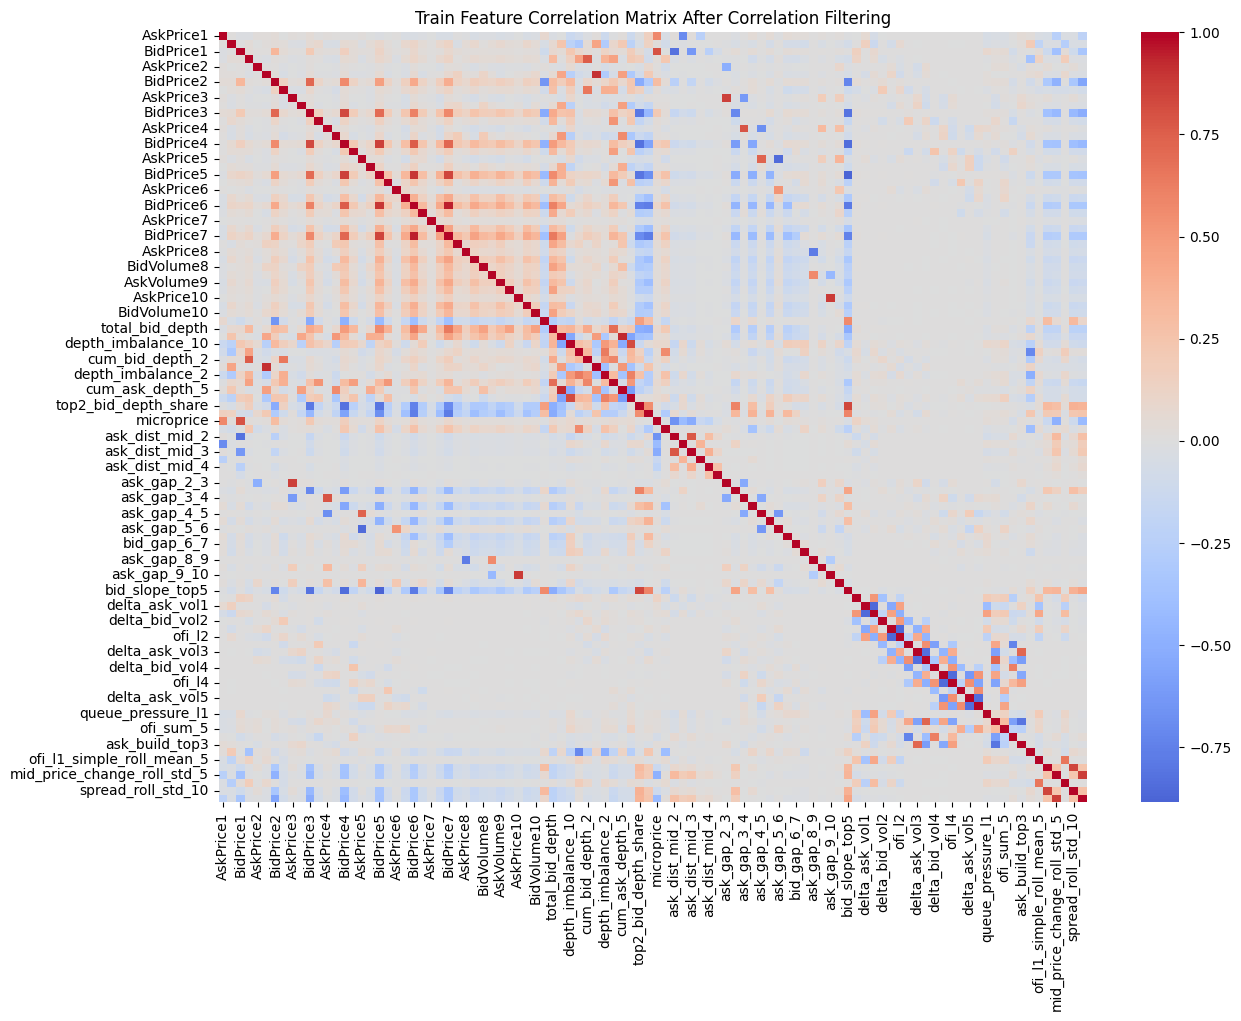

In [ ]:
#HEATMAP OF TRAIN FEATURES AFTER CORRELATION FILTER
plt.figure(figsize=(14, 10))
sns.heatmap(X_train.corr(), cmap="coolwarm", center=0)
plt.title("Train Feature Correlation Matrix After Correlation Filtering")
plt.show()

In [ ]:
# ------------------------------------------------------------
# FINAL OBJECTS READY FOR MODELING
# ------------------------------------------------------------
X_train_final = X_train_selected
X_val_final = X_val_selected
X_test_final = X_test_selected

y_train_final = y_train
y_val_final = y_val
y_test_final = y_test

print("\nFeature selection completed successfully.")
print("Use X_train_final, X_val_final, y_train_final, y_val_final for modeling.")


Feature selection completed successfully.
Use X_train_final, X_val_final, y_train_final, y_val_final for modeling.


SCALING

Chose standart scaling because of Ntakaris(2018) MinMax scaling and Standart Scaling Comparison

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val_final)
X_test_scaled = scaler.transform(X_test_final)

Checking the imbalance for tuning the threshold

In [ ]:
print(y_train_final.value_counts(normalize=True))

label
1    0.540254
0    0.233681
2    0.226065
Name: proportion, dtype: float64


There is a quite imbalance, but found out that is distribution optimizes my models after trying different thresholds, so kept the threshold at 0.0001.

# MODEL SELECTION

## BASELINE MODEL (Logistic Regression)

In [ ]:
lr = LogisticRegression(
    max_iter=1000,
    C=0.1,
    class_weight='balanced'
)
lr.fit(X_train_scaled, y_train_final)


y_val_pred_lr = lr.predict(X_val_scaled)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_val_final, y_val_pred_lr))
print("Macro F1:", f1_score(y_val_final, y_val_pred_lr, average='macro'))

print("\nClassification Report:")
print(classification_report(y_val_final, y_val_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_final, y_val_pred_lr))

=== Logistic Regression ===
Accuracy: 0.40423968090350915
Macro F1: 0.3636675661658651

Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.16      0.20     25842
           1       0.53      0.45      0.49     55932
           2       0.33      0.53      0.41     29791

    accuracy                           0.40    111565
   macro avg       0.37      0.38      0.36    111565
weighted avg       0.41      0.40      0.40    111565


Confusion Matrix:
[[ 4163 11523 10156]
 [ 9351 25189 21392]
 [ 3176 10868 15747]]


MODEL REJECTION: Logistic Regression

LR achieves Macro F1 of 0.36 — rejected as primary model because

it assumes linear decision boundaries, which are insufficient for

capturing non-linear LOB microstructure dynamics.

Retained as baseline for comparison purposes.

## MLP MODEL

GPU Configuration (T4)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU name: Tesla T4


In [ ]:
# ------------------------------------------------------------
# CONVERTING DATA TO TORCH TENSORS
# ------------------------------------------------------------

X_train_t = torch.tensor(np.asarray(X_train_scaled), dtype=torch.float32)
X_val_t   = torch.tensor(np.asarray(X_val_scaled), dtype=torch.float32)
X_test_t  = torch.tensor(np.asarray(X_test_scaled), dtype=torch.float32)

y_train_t = torch.tensor(np.asarray(y_train_final), dtype=torch.long)
y_val_t   = torch.tensor(np.asarray(y_val_final), dtype=torch.long)
y_test_t  = torch.tensor(np.asarray(y_test_final), dtype=torch.long)

print("Train tensor shape:", X_train_t.shape)
print("Val tensor shape  :", X_val_t.shape)
print("Test tensor shape :", X_test_t.shape)

Train tensor shape: torch.Size([335820, 60])
Val tensor shape  : torch.Size([111940, 60])
Test tensor shape : torch.Size([111940, 60])


In [ ]:
# ------------------------------------------------------------
# DATALOADERS
# ------------------------------------------------------------
batch_size = 4096  # standart

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

In [ ]:
# ------------------------------------------------------------
# RUN 3 REASONABLE MLP CONFIGURATIONS (BASED ON MY EMPIRICAL EXPERIMENTS, BIG MODELS OVERFIT, REGULARIZATION LIKE DROPOUT HELPED A LOT)
# ------------------------------------------------------------
mlp_configs = [
    {
        "name": "MLP Tiny Weighted CE",
        "hidden_layers": (64, 32),
        "dropout": 0.3,
        "lr": 0.001,
        "weight_decay": 1e-4,
        "loss": "weighted_ce"
    },
    {
        "name": "MLP Small Weighted CE",
        "hidden_layers": (128, 64),
        "dropout": 0.2,
        "lr": 0.001,
        "weight_decay": 1e-4,
        "loss": "weighted_ce"
    },
    {
        "name": "MLP Small Weighted CE HighDropout",
        "hidden_layers": (128, 64),
        "dropout": 0.4,
        "lr": 0.001,
        "weight_decay": 1e-4,
        "loss": "weighted_ce"
    },
    {
        "name": "MLP Medium Focal",
        "hidden_layers": (128, 64),
        "dropout": 0.1,
        "lr": 0.001,
        "weight_decay": 1e-4,
        "loss": "focal"
    },
]


results = []

for cfg in mlp_configs:
    print("\n" + "=" * 80)
    print(f"Training {cfg['name']}")
    print(f"Hidden layers : {cfg['hidden_layers']}")
    print(f"Dropout       : {cfg['dropout']}")
    print(f"Learning rate : {cfg['lr']}")
    print(f"Weight decay  : {cfg['weight_decay']}")
    print("=" * 80)

    model = MLPNet(
        input_dim=X_train_t.shape[1],
        hidden_layers=cfg["hidden_layers"],
        num_classes=3,
        dropout=cfg["dropout"]
    )

    model, history = train_mlp_torch(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        y_train_array=y_train,
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
        max_epochs=120,
        patience=15
    )

    val_loss, val_acc, val_macro_f1, y_val_true, y_val_pred = evaluate_model(model, val_loader, device)

    print("\nValidation Results")
    print("Val Loss    :", round(val_loss, 4))
    print("Val Accuracy:", round(val_acc, 4))
    print("Val Macro F1:", round(val_macro_f1, 4))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val_true, y_val_pred))
    print("\nClassification Report:")
    print(classification_report(y_val_true, y_val_pred, digits=4))

    results.append({
        "name": cfg["name"],
        "hidden_layers": cfg["hidden_layers"],
        "dropout": cfg["dropout"],
        "lr": cfg["lr"],
        "weight_decay": cfg["weight_decay"],
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_macro_f1": val_macro_f1,
        "model": model,
        "history": history
    })

results_sorted = sorted(results, key=lambda x: x["val_macro_f1"], reverse=True)

print("\n" + "=" * 80)
print("SUMMARY OF GPU MLP RESULTS")
print("=" * 80)
for r in results_sorted:
    print(
        f"{r['name']:15s} | "
        f"layers={str(r['hidden_layers']):18s} | "
        f"lr={r['lr']:<8} | "
        f"wd={r['weight_decay']:<8} | "
        f"Val Acc={r['val_acc']:.4f} | "
        f"Val Macro F1={r['val_macro_f1']:.4f}"
    )

best_result = results_sorted[0]
best_model = best_result["model"]

print("\nBest model:")
print(best_result["name"])
print("Hidden layers :", best_result["hidden_layers"])
print("Learning rate :", best_result["lr"])
print("Weight decay  :", best_result["weight_decay"])
print("Val Accuracy  :", round(best_result["val_acc"], 4))
print("Val Macro F1  :", round(best_result["val_macro_f1"], 4))


Training MLP Tiny Weighted CE
Hidden layers : (64, 32)
Dropout       : 0.3
Learning rate : 0.001
Weight decay  : 0.0001
Epoch 001 | Train Loss: 1.0564 | Val Loss: 1.0675 | Val Acc: 0.4333 | Val Macro F1: 0.3651 | LR: 0.001000
Epoch 002 | Train Loss: 1.0233 | Val Loss: 1.0703 | Val Acc: 0.4190 | Val Macro F1: 0.3714 | LR: 0.001000
Epoch 003 | Train Loss: 1.0043 | Val Loss: 1.0669 | Val Acc: 0.4282 | Val Macro F1: 0.3657 | LR: 0.001000
Epoch 004 | Train Loss: 0.9924 | Val Loss: 1.0677 | Val Acc: 0.4279 | Val Macro F1: 0.3730 | LR: 0.001000
Epoch 005 | Train Loss: 0.9851 | Val Loss: 1.0705 | Val Acc: 0.4113 | Val Macro F1: 0.3790 | LR: 0.001000
Epoch 006 | Train Loss: 0.9790 | Val Loss: 1.0709 | Val Acc: 0.4120 | Val Macro F1: 0.3796 | LR: 0.001000
Epoch 007 | Train Loss: 0.9740 | Val Loss: 1.0699 | Val Acc: 0.4063 | Val Macro F1: 0.3764 | LR: 0.001000
Epoch 008 | Train Loss: 0.9699 | Val Loss: 1.0715 | Val Acc: 0.3955 | Val Macro F1: 0.3796 | LR: 0.001000
Epoch 009 | Train Loss: 0.9674 

In [ ]:
print("\n" + "=" * 80)
print("ALL MODELS - TEST RESULTS")
print("=" * 80)

test_results = []

for r in results:
    test_loss, test_acc, test_macro_f1, y_test_true, y_test_pred = evaluate_model(
        r["model"], test_loader, device
    )

    print(f"\n{'=' * 60}")
    print(f"Model: {r['name']}")
    print(f"{'=' * 60}")
    print("Test Loss    :", round(test_loss, 4))
    print("Test Accuracy:", round(test_acc, 4))
    print("Test Macro F1:", round(test_macro_f1, 4))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_true, y_test_pred))
    print("\nClassification Report:")
    print(classification_report(y_test_true, y_test_pred, digits=4))

    test_results.append({
        "name": r["name"],
        "val_macro_f1": r["val_macro_f1"],
        "test_acc": test_acc,
        "test_macro_f1": test_macro_f1,
    })

# Summary table
print("\n" + "=" * 80)
print("MLP FINAL COMPARISON TABLE")
print("=" * 80)
print(f"{'Model':<35} {'Val F1':<12} {'Test F1':<12}")
print("-" * 60)
for r in sorted(test_results, key=lambda x: x["test_macro_f1"], reverse=True):
    print(f"{r['name']:<35} {r['val_macro_f1']:.4f}       {r['test_macro_f1']:.4f}")

best = max(test_results, key=lambda x: x["test_macro_f1"])
print(f"\nBest model: {best['name']} — Test F1: {best['test_macro_f1']:.4f}")


ALL MODELS - TEST RESULTS

Model: MLP Tiny Weighted CE
Test Loss    : 1.0358
Test Accuracy: 0.4419
Test Macro F1: 0.3863

Confusion Matrix:
[[ 4877 10570  7229]
 [16696 33217 12960]
 [ 3560 11457 11374]]

Classification Report:
              precision    recall  f1-score   support

           0     0.1940    0.2151    0.2040     22676
           1     0.6013    0.5283    0.5624     62873
           2     0.3604    0.4310    0.3925     26391

    accuracy                         0.4419    111940
   macro avg     0.3852    0.3915    0.3863    111940
weighted avg     0.4620    0.4419    0.4498    111940


Model: MLP Small Weighted CE
Test Loss    : 1.009
Test Accuracy: 0.495
Test Macro F1: 0.427

Confusion Matrix:
[[ 5608  9825  7243]
 [10556 38155 14162]
 [ 4051 10695 11645]]

Classification Report:
              precision    recall  f1-score   support

           0     0.2774    0.2473    0.2615     22676
           1     0.6503    0.6069    0.6278     62873
           2     0.3523    

MODEL SELECTION & REJECTION — MLP

Selected: MLP Small (128, 64), dropout=0.4, Weighted CE — Test F1: 0.4342

Rejected configs: Tiny (insufficient capacity), Deep (overfitting),

Focal Loss (too aggressive for noisy LOB data).

MLP rejected as primary model — no temporal modelling capability.

Retained in ensemble where it contributes complementary predictions.


# RBFNN

In [ ]:
rbf_results = []

for n_centers in [50, 100, 150]:
    print("\n" + "=" * 80)
    print(f"Training RBFNN with {n_centers} centers")
    print("=" * 80)

    model_rbf = train_rbfnn(
        X_train=X_train_scaled,
        y_train=np.asarray(y_train),
        X_val=X_val_scaled,
        y_val=np.asarray(y_val),
        n_centers=n_centers,
        kmeans_sample_size=50000,
        random_state=42,
        C=1.0
    )

    rbf_results.append({
        "n_centers": n_centers,
        "val_accuracy": model_rbf["val_accuracy"],
        "val_macro_f1": model_rbf["val_macro_f1"],
        "model": model_rbf
    })

rbf_results = sorted(rbf_results, key=lambda x: x["val_macro_f1"], reverse=True)

print("\n" + "=" * 80)
print("RBFNN VALIDATION SUMMARY")
print("=" * 80)
for r in rbf_results:
    print(
        f"Centers={r['n_centers']:3d} | "
        f"Val Acc={r['val_accuracy']:.4f} | "
        f"Val Macro F1={r['val_macro_f1']:.4f}"
    )

best_rbf = rbf_results[0]["model"]
print("\nBest RBFNN center count:", rbf_results[0]["n_centers"])
print("Best validation macro F1:", round(rbf_results[0]["val_macro_f1"], 4))


Training RBFNN with 50 centers
Fitting KMeans with 50 centers on 50000 samples...
Computed RBF sigma: 23.141416
Transforming training and validation data into RBF space...
RBF feature shapes:
Phi_train: (335820, 50)
Phi_val  : (111940, 50)

Validation Results
Accuracy   : 0.4455
Macro F1   : 0.3574

Confusion Matrix:
[[ 3279 17720  4978]
 [ 7130 37681 11446]
 [ 2520 18280  8906]]

Classification Report:
              precision    recall  f1-score   support

           0     0.2536    0.1262    0.1686     25977
           1     0.5114    0.6698    0.5800     56257
           2     0.3516    0.2998    0.3236     29706

    accuracy                         0.4455    111940
   macro avg     0.3722    0.3653    0.3574    111940
weighted avg     0.4092    0.4455    0.4165    111940


Training RBFNN with 100 centers
Fitting KMeans with 100 centers on 50000 samples...
Computed RBF sigma: 17.336048
Transforming training and validation data into RBF space...
RBF feature shapes:
Phi_train: (3358

In [ ]:
print("\n" + "=" * 80)
print("ALL RBFNN MODELS - TEST RESULTS")
print("=" * 80)

rbf_test_results = []

for r in rbf_results:
    print(f"\n{'=' * 60}")
    print(f"Model: RBFNN Centers={r['n_centers']}")
    print(f"{'=' * 60}")

    test_acc, test_macro_f1, y_test_pred = evaluate_rbfnn_on_test(
        model_dict=r["model"],
        X_test=X_test_scaled,
        y_test=np.asarray(y_test)
    )

    rbf_test_results.append({
        "n_centers": r["n_centers"],
        "val_macro_f1": r["val_macro_f1"],
        "test_macro_f1": test_macro_f1,
        "test_acc": test_acc,
    })

# Summary table
print("\n" + "=" * 80)
print("RBFNN FINAL COMPARISON TABLE")
print("=" * 80)
print(f"{'Centers':<12} {'Val F1':<12} {'Test F1':<12}")
print("-" * 36)
for r in sorted(rbf_test_results, key=lambda x: x["test_macro_f1"], reverse=True):
    print(f"{r['n_centers']:<12} {r['val_macro_f1']:.4f}       {r['test_macro_f1']:.4f}")

best_rbf_test = max(rbf_test_results, key=lambda x: x["test_macro_f1"])
print(f"\nBest RBFNN: Centers={best_rbf_test['n_centers']} — Test F1: {best_rbf_test['test_macro_f1']:.4f}")


ALL RBFNN MODELS - TEST RESULTS

Model: RBFNN Centers=150

Test Results
Accuracy   : 0.3758
Macro F1   : 0.3447

Confusion Matrix:
[[ 5350 10742  6584]
 [20709 25491 16673]
 [ 3974 11193 11224]]

Classification Report:
              precision    recall  f1-score   support

           0     0.1781    0.2359    0.2030     22676
           1     0.5375    0.4054    0.4622     62873
           2     0.3255    0.4253    0.3688     26391

    accuracy                         0.3758    111940
   macro avg     0.3470    0.3556    0.3447    111940
weighted avg     0.4147    0.3758    0.3877    111940


Model: RBFNN Centers=100

Test Results
Accuracy   : 0.4653
Macro F1   : 0.3878

Confusion Matrix:
[[ 4028 12180  6468]
 [ 9814 37290 15769]
 [ 2746 12880 10765]]

Classification Report:
              precision    recall  f1-score   support

           0     0.2428    0.1776    0.2052     22676
           1     0.5981    0.5931    0.5956     62873
           2     0.3262    0.4079    0.3625     2

MODEL SELECTION & REJECTION — RBFNN

Selected: 100 centers — Test F1: 0.3878

Rejected configs: 150 centers (overfitting, val F1 best but test worst),

50 centers (insufficient representational capacity).

RBFNN rejected as primary model — no temporal modelling capability.


# CNN/LSTM

In [ ]:
df_cnn = create_cnn_lstm_features(df)
df_cnn = create_labels(df_cnn)

print("CNN dataframe shape:", df_cnn.shape)


cnn_feature_cols = get_cnn_lstm_feature_columns(df_cnn, mode="extended")
print("Number of CNN-LSTM features:", len(cnn_feature_cols))

# ------------------------------------------------------------
# MODEL CONFIGURATIONS (Made wiser choices based on MLP training)
# ------------------------------------------------------------
cnn_configs = [
    {
        "name": "CNN-LSTM Tiny dropout03",
        "seq_len": 10,
        "conv_channels": 32,
        "lstm_hidden": 32,
        "lstm_layers": 1,
        "dropout": 0.3,
    },
    {
        "name": "CNN-LSTM Tiny dropout04",
        "seq_len": 10,
        "conv_channels": 32,
        "lstm_hidden": 32,
        "lstm_layers": 1,
        "dropout": 0.4,
    },
    {
        "name": "CNN-LSTM Tiny 2Layer",
        "seq_len": 10,
        "conv_channels": 32,
        "lstm_hidden": 32,
        "lstm_layers": 2,
        "dropout": 0.3,
    },
]

cnn_results = []

for cfg in cnn_configs:
    print("\n" + "=" * 80)
    print(f"Training: {cfg['name']}")
    print(f"seq_len={cfg['seq_len']} | conv={cfg['conv_channels']} | lstm={cfg['lstm_hidden']} | layers={cfg['lstm_layers']} | dropout={cfg['dropout']}")
    print("=" * 80)


    X_seq, y_seq = make_sequence_dataset(
        df=df_cnn,
        feature_cols=cnn_feature_cols,
        label_col="label",
        seq_len=cfg["seq_len"]
    )


    n = len(X_seq)
    train_end = int(n * 0.6)
    val_end = int(n * 0.8)

    X_train_seq = X_seq[:train_end]
    X_val_seq = X_seq[train_end:val_end]
    X_test_seq = X_seq[val_end:]

    y_train_seq = y_seq[:train_end]
    y_val_seq = y_seq[train_end:val_end]
    y_test_seq = y_seq[val_end:]


    X_train_seq_scaled, X_val_seq_scaled, X_test_seq_scaled, seq_scaler = scale_sequence_data(
        X_train_seq, X_val_seq, X_test_seq
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_train_t = torch.tensor(X_train_seq_scaled, dtype=torch.float32)
    X_val_t = torch.tensor(X_val_seq_scaled, dtype=torch.float32)
    X_test_t = torch.tensor(X_test_seq_scaled, dtype=torch.float32)

    y_train_t = torch.tensor(y_train_seq, dtype=torch.long)
    y_val_t = torch.tensor(y_val_seq, dtype=torch.long)
    y_test_t = torch.tensor(y_test_seq, dtype=torch.long)

    batch_size = 1024

    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)


    cnn_lstm_model = CNNLSTM(
        num_features=X_train_seq_scaled.shape[2],
        conv_channels=cfg["conv_channels"],
        lstm_hidden=cfg["lstm_hidden"],
        lstm_layers=cfg["lstm_layers"],
        dropout=cfg["dropout"],
        num_classes=3
    )


    cnn_lstm_model, cnn_lstm_history = train_cnn_lstm(
        model=cnn_lstm_model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        y_train_array=y_train_seq,
        lr=0.001,
        weight_decay=1e-4,
        max_epochs=100,
        patience=15
    )


    val_loss, val_acc, val_macro_f1, y_val_true, y_val_pred = evaluate_torch_model(
        cnn_lstm_model, val_loader, device
    )

    print(f"\n{cfg['name']} — Validation Results")
    print("Val Accuracy :", round(val_acc, 4))
    print("Val Macro F1 :", round(val_macro_f1, 4))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val_true, y_val_pred))
    print("\nClassification Report:")
    print(classification_report(y_val_true, y_val_pred, digits=4))

    #TEST EVALUATION
    test_loss, test_acc, test_macro_f1, y_test_true, y_test_pred = evaluate_torch_model(
        cnn_lstm_model, test_loader, device
    )

    print(f"\n{cfg['name']} — Test Results")
    print("Test Accuracy :", round(test_acc, 4))
    print("Test Macro F1 :", round(test_macro_f1, 4))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_true, y_test_pred))
    print("\nClassification Report:")
    print(classification_report(y_test_true, y_test_pred, digits=4))

    cnn_results.append({
        "name": cfg["name"],
        "conv_channels": cfg["conv_channels"],
        "lstm_hidden": cfg["lstm_hidden"],
        "lstm_layers": cfg["lstm_layers"],
        "dropout": cfg["dropout"],
        "val_macro_f1": val_macro_f1,
        "test_macro_f1": test_macro_f1,
        "test_acc": test_acc,
        "model": cnn_lstm_model
    })

#RESULTS
print("\n" + "=" * 80)
print("CNN-LSTM COMPARISON TABLE")
print("=" * 80)
print(f"{'Model':<25} {'Conv':<8} {'LSTM':<8} {'Layers':<8} {'Dropout':<10} {'Val F1':<10} {'Test F1':<10}")
print("-" * 80)
for r in sorted(cnn_results, key=lambda x: x["test_macro_f1"], reverse=True):
    print(
        f"{r['name']:<25} "
        f"{r['conv_channels']:<8} "
        f"{r['lstm_hidden']:<8} "
        f"{r['lstm_layers']:<8} "
        f"{r['dropout']:<10} "
        f"{r['val_macro_f1']:.4f}     "
        f"{r['test_macro_f1']:.4f}"
    )

best_cnn = max(cnn_results, key=lambda x: x["test_macro_f1"])
print(f"\nBest model: {best_cnn['name']} — Test F1: {best_cnn['test_macro_f1']:.4f}")

CNN dataframe shape: (559686, 155)
Number of CNN-LSTM features: 59

Training: CNN-LSTM Tiny dropout03
seq_len=10 | conv=32 | lstm=32 | layers=1 | dropout=0.4
Epoch 001 | Train Loss: 1.0028 | Val Loss: 1.0808 | Val Acc: 0.4463 | Val Macro F1: 0.3853 | LR: 0.001000
Epoch 002 | Train Loss: 0.9676 | Val Loss: 1.0840 | Val Acc: 0.4709 | Val Macro F1: 0.3840 | LR: 0.001000
Epoch 003 | Train Loss: 0.9568 | Val Loss: 1.0744 | Val Acc: 0.4467 | Val Macro F1: 0.4007 | LR: 0.001000
Epoch 004 | Train Loss: 0.9511 | Val Loss: 1.0772 | Val Acc: 0.4567 | Val Macro F1: 0.4031 | LR: 0.001000
Epoch 005 | Train Loss: 0.9457 | Val Loss: 1.0748 | Val Acc: 0.4619 | Val Macro F1: 0.4010 | LR: 0.001000
Epoch 006 | Train Loss: 0.9425 | Val Loss: 1.0769 | Val Acc: 0.4578 | Val Macro F1: 0.4065 | LR: 0.001000
Epoch 007 | Train Loss: 0.9391 | Val Loss: 1.0738 | Val Acc: 0.4398 | Val Macro F1: 0.4031 | LR: 0.001000
Epoch 008 | Train Loss: 0.9370 | Val Loss: 1.0724 | Val Acc: 0.4479 | Val Macro F1: 0.4101 | LR: 0.0

MODEL SELECTION & REJECTION — CNN-LSTM

Selected: Tiny (conv=32, lstm=32, layers=1, dropout=0.4) — Test F1: 0.4490

Rejected configs: larger architectures (conv=64+, lstm=64+) overfit severely.

2-layer LSTM improved val F1 but generalised worse than 1-layer.

dropout=0.3 rejected in favour of dropout=0.4 — reduced val-test gap.

Key finding: smaller models generalise better on noisy single-day LOB data.

# BERT

In [ ]:
seq_len = 10

df_bert = create_cnn_lstm_features(df)
df_bert = create_labels(df_bert)

bert_feature_cols = get_cnn_lstm_feature_columns(df_bert, mode="extended")
print("BERT feature cols:", len(bert_feature_cols))

X_seq, y_seq = make_sequence_dataset(
    df=df_bert,
    feature_cols=bert_feature_cols,
    label_col="label",
    seq_len=seq_len
)

n = len(X_seq)
train_end = int(n * 0.60)
val_end = int(n * 0.80)

X_train_seq = X_seq[:train_end]
X_val_seq   = X_seq[train_end:val_end]
X_test_seq  = X_seq[val_end:]

y_train_seq = y_seq[:train_end]
y_val_seq   = y_seq[train_end:val_end]
y_test_seq  = y_seq[val_end:]

X_train_seq_scaled, X_val_seq_scaled, X_test_seq_scaled, bert_scaler = scale_sequence_data(
    X_train_seq, X_val_seq, X_test_seq
)

X_train_t = torch.tensor(X_train_seq_scaled, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_seq_scaled,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_seq_scaled,  dtype=torch.float32)

y_train_t = torch.tensor(y_train_seq, dtype=torch.long)
y_val_t   = torch.tensor(y_val_seq,   dtype=torch.long)
y_test_t  = torch.tensor(y_test_seq,  dtype=torch.long)

batch_size = 1024

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t,   y_val_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, pin_memory=True)

for X_batch, _ in train_loader:
    print("Batch shape:", X_batch.shape)
    break

BERT feature cols: 59
Batch shape: torch.Size([1024, 10, 59])


In [ ]:
bert_configs = [
    {
        "name": "BERT Tiny",
        "d_model": 64,
        "nhead": 4,
        "num_layers": 1,
        "dim_feedforward": 128,
        "dropout": 0.4,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "max_epochs": 100,
        "patience": 15,
    },
    {
        "name": "BERT Small",
        "d_model": 128,
        "nhead": 4,
        "num_layers": 2,
        "dim_feedforward": 256,
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "max_epochs": 100,
        "patience": 15,
    },
    {
        "name": "BERT Small LowLR",
        "d_model": 128,
        "nhead": 4,
        "num_layers": 2,
        "dim_feedforward": 256,
        "dropout": 0.3,
        "lr": 5e-4,
        "weight_decay": 1e-4,
        "max_epochs": 100,
        "patience": 15,
    },
]

bert_results = []

for cfg in bert_configs:
    print("\n" + "=" * 80)
    print(f"Training: {cfg['name']}")
    print(f"d_model={cfg['d_model']} | nhead={cfg['nhead']} | layers={cfg['num_layers']} | ff={cfg['dim_feedforward']} | dropout={cfg['dropout']} | lr={cfg['lr']}")
    print("=" * 80)

    lob_bert_model = LOBBERT(
        input_dim=X_train_seq_scaled.shape[2],
        seq_len=seq_len,
        d_model=cfg["d_model"],
        nhead=cfg["nhead"],
        num_layers=cfg["num_layers"],
        dim_feedforward=cfg["dim_feedforward"],
        dropout=cfg["dropout"],
        num_classes=3
    )

    lob_bert_model, lob_bert_history = train_lob_bert(
        model=lob_bert_model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        y_train_array=y_train_seq,
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
        max_epochs=cfg["max_epochs"],
        patience=cfg["patience"]
    )

    # Validation
    val_loss, val_acc, val_macro_f1, y_val_true, y_val_pred = evaluate_torch_model(
        lob_bert_model, val_loader, device
    )

    print(f"\n{cfg['name']} — Validation Results")
    print("Val Accuracy :", round(val_acc, 4))
    print("Val Macro F1 :", round(val_macro_f1, 4))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val_true, y_val_pred))
    print("\nClassification Report:")
    print(classification_report(y_val_true, y_val_pred, digits=4))

    # Test
    test_loss, test_acc, test_macro_f1, y_test_true, y_test_pred = evaluate_torch_model(
        lob_bert_model, test_loader, device
    )

    print(f"\n{cfg['name']} — Test Results")
    print("Test Accuracy :", round(test_acc, 4))
    print("Test Macro F1 :", round(test_macro_f1, 4))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_true, y_test_pred))
    print("\nClassification Report:")
    print(classification_report(y_test_true, y_test_pred, digits=4))

    bert_results.append({
        "name": cfg["name"],
        "d_model": cfg["d_model"],
        "num_layers": cfg["num_layers"],
        "dropout": cfg["dropout"],
        "lr": cfg["lr"],
        "val_macro_f1": val_macro_f1,
        "test_macro_f1": test_macro_f1,
        "test_acc": test_acc,
        "model": lob_bert_model
    })

# Summary table
print("\n" + "=" * 80)
print("LOB-BERT COMPARISON TABLE")
print("=" * 80)
print(f"{'Model':<25} {'d_model':<10} {'Layers':<10} {'Dropout':<10} {'LR':<10} {'Val F1':<10} {'Test F1':<10}")
print("-" * 85)
for r in sorted(bert_results, key=lambda x: x["test_macro_f1"], reverse=True):
    print(
        f"{r['name']:<25} "
        f"{r['d_model']:<10} "
        f"{r['num_layers']:<10} "
        f"{r['dropout']:<10} "
        f"{r['lr']:<10} "
        f"{r['val_macro_f1']:.4f}     "
        f"{r['test_macro_f1']:.4f}"
    )

best_bert = max(bert_results, key=lambda x: x["test_macro_f1"])
print(f"\nBest BERT: {best_bert['name']} — Test F1: {best_bert['test_macro_f1']:.4f}")


Training: BERT Tiny
d_model=64 | nhead=4 | layers=1 | ff=128 | dropout=0.4 | lr=0.001
Epoch 001 | Train Loss: 1.0154 | Val Loss: 1.0812 | Val Acc: 0.4602 | Val Macro F1: 0.3580 | LR: 0.001000
Epoch 002 | Train Loss: 0.9894 | Val Loss: 1.0766 | Val Acc: 0.4657 | Val Macro F1: 0.3776 | LR: 0.001000
Epoch 003 | Train Loss: 0.9830 | Val Loss: 1.0738 | Val Acc: 0.4624 | Val Macro F1: 0.4040 | LR: 0.001000
Epoch 004 | Train Loss: 0.9793 | Val Loss: 1.0714 | Val Acc: 0.4583 | Val Macro F1: 0.4109 | LR: 0.001000
Epoch 005 | Train Loss: 0.9760 | Val Loss: 1.0713 | Val Acc: 0.4477 | Val Macro F1: 0.4147 | LR: 0.001000
Epoch 006 | Train Loss: 0.9744 | Val Loss: 1.0669 | Val Acc: 0.4378 | Val Macro F1: 0.4168 | LR: 0.001000
Epoch 007 | Train Loss: 0.9726 | Val Loss: 1.0685 | Val Acc: 0.4526 | Val Macro F1: 0.4221 | LR: 0.001000
Epoch 008 | Train Loss: 0.9715 | Val Loss: 1.0702 | Val Acc: 0.4676 | Val Macro F1: 0.4143 | LR: 0.001000
Epoch 009 | Train Loss: 0.9700 | Val Loss: 1.0632 | Val Acc: 0.45

MODEL SELECTION & REJECTION — LOB-BERT
Selected: BERT Tiny (d_model=64, layers=1, dropout=0.4) — Test F1: 0.4515
Rejected configs: BERT Small (d_model=128, layers=2) overfit despite
lower LR.

Larger capacity unnecessary for 10-event sequences.

dropout=0.3 rejected in favour of dropout=0.4 — consistent with MLP/CNN findings.

Key finding: architectural complexity does not improve generalisation on noisy LOB data.

## TRYING ENSEMBLE MODELS (CNN-LSTM, LOB-BERT AND CNN-LSTM, LOB-BERT, MLP)

In [ ]:
best_cnn_model = max(cnn_results, key=lambda x: x["test_macro_f1"])["model"]
best_bert_model = max(bert_results, key=lambda x: x["test_macro_f1"])["model"]

print("Best CNN-LSTM:", max(cnn_results, key=lambda x: x["test_macro_f1"])["name"])
print("Best BERT    :", max(bert_results, key=lambda x: x["test_macro_f1"])["name"])

Best CNN-LSTM: CNN-LSTM Tiny dropout04
Best BERT    : BERT Tiny


In [ ]:
X_test_mlp_t = torch.tensor(np.asarray(X_test_scaled), dtype=torch.float32)
y_test_mlp_t = torch.tensor(np.asarray(y_test_final), dtype=torch.long)

mlp_test_dataset = TensorDataset(X_test_mlp_t, y_test_mlp_t)
mlp_test_loader = DataLoader(
    mlp_test_dataset,
    batch_size=4096,
    shuffle=False,
    pin_memory=True
)

print("MLP test size     :", len(mlp_test_loader.dataset))
print("CNN/BERT test size:", len(test_loader.dataset))

MLP test size     : 111940
CNN/BERT test size: 111936


**CNN-LSTM, BERT ENSEMBLE:**

In [ ]:

probs_cnn = get_probs(best_cnn_model, test_loader, device)
probs_bert = get_probs(best_bert_model, test_loader, device)

ensemble_probs = (probs_cnn + probs_bert) / 2
ensemble_preds = np.argmax(ensemble_probs, axis=1)

print("Ensemble Test Macro F1:", f1_score(y_test_seq, ensemble_preds, average="macro"))
print(classification_report(y_test_seq, ensemble_preds, digits=4))

Ensemble Test Macro F1: 0.4571941591461184
              precision    recall  f1-score   support

           0     0.3019    0.2784    0.2897     22666
           1     0.6971    0.6324    0.6632     62873
           2     0.3719    0.4790    0.4187     26397

    accuracy                         0.5246    111936
   macro avg     0.4570    0.4633    0.4572    111936
weighted avg     0.5404    0.5246    0.5299    111936



## BEST RESULT

**CNN-LSTM, BERT, MLP ENSEMBLE:**

In [ ]:
X_test_mlp_t = X_test_mlp_t[:111936]
y_test_mlp_t = y_test_mlp_t[:111936]

mlp_test_dataset = TensorDataset(X_test_mlp_t, y_test_mlp_t)
mlp_test_loader = DataLoader(
    mlp_test_dataset,
    batch_size=4096,
    shuffle=False,
    pin_memory=True
)

probs_mlp = get_probs(best_mlp_model, mlp_test_loader, device)

ensemble_probs_3 = (probs_cnn + probs_bert + probs_mlp) / 3
ensemble_preds_3 = np.argmax(ensemble_probs_3, axis=1)


y_test_ensemble = y_test_seq

print("3-Model Ensemble Test Macro F1:",
      f1_score(y_test_ensemble, ensemble_preds_3, average="macro"))
print(classification_report(y_test_ensemble, ensemble_preds_3, digits=4))

3-Model Ensemble Test Macro F1: 0.4641148139377877
              precision    recall  f1-score   support

           0     0.3170    0.2685    0.2908     22666
           1     0.7038    0.6534    0.6777     62873
           2     0.3748    0.4879    0.4239     26397

    accuracy                         0.5364    111936
   macro avg     0.4652    0.4699    0.4641    111936
weighted avg     0.5479    0.5364    0.5395    111936



In [ ]:
weight_configs = [
    (0.2, 0.4, 0.4),
    (0.1, 0.4, 0.5),
    (0.1, 0.5, 0.4),
    (0.2, 0.3, 0.5),
    (0.3, 0.3, 0.4),
    (0.2, 0.2, 0.6),
    (0.33, 0.33, 0.34),
]

weighted_results = []

for w_mlp, w_cnn, w_bert in weight_configs:
    ensemble_probs_w = (
        w_mlp  * probs_mlp +
        w_cnn  * probs_cnn +
        w_bert * probs_bert
    )
    ensemble_preds_w = np.argmax(ensemble_probs_w, axis=1)
    macro_f1 = f1_score(y_test_ensemble, ensemble_preds_w, average="macro")

    weighted_results.append({
        "w_mlp": w_mlp,
        "w_cnn": w_cnn,
        "w_bert": w_bert,
        "test_macro_f1": macro_f1
    })

# Summary
print("=" * 70)
print("WEIGHTED ENSEMBLE RESULTS")
print("=" * 70)
print(f"{'MLP':>8} {'CNN':>8} {'BERT':>8} {'Test F1':>12}")
print("-" * 40)
for r in sorted(weighted_results, key=lambda x: x["test_macro_f1"], reverse=True):
    print(f"{r['w_mlp']:>8.2f} {r['w_cnn']:>8.2f} {r['w_bert']:>8.2f} {r['test_macro_f1']:>12.4f}")

best_w = max(weighted_results, key=lambda x: x["test_macro_f1"])
print(f"\nBest weights — MLP: {best_w['w_mlp']} | CNN: {best_w['w_cnn']} | BERT: {best_w['w_bert']}")
print(f"Best weighted ensemble F1: {best_w['test_macro_f1']:.4f}")

WEIGHTED ENSEMBLE RESULTS
     MLP      CNN     BERT      Test F1
----------------------------------------
    0.33     0.33     0.34       0.4640
    0.30     0.30     0.40       0.4620
    0.20     0.20     0.60       0.4614
    0.10     0.40     0.50       0.4602
    0.20     0.30     0.50       0.4600
    0.20     0.40     0.40       0.4596
    0.10     0.50     0.40       0.4593

Best weights — MLP: 0.33 | CNN: 0.33 | BERT: 0.34
Best weighted ensemble F1: 0.4640


MODEL SELECTION — Ensemble (CNN-LSTM + LOB-BERT + MLP)

Final selected model: 3-model ensemble — Test Macro F1: 0.4641

Equal weights (1/3, 1/3, 1/3) outperformed all weighted combinations.

Rejected: 2-model ensemble (CNN-LSTM + LOB-BERT, F1: 0.4572) —

adding MLP improved generalisation despite MLP's lower individual F1.

Rejected: weighted ensemble — equal weighting proved optimal,

confirming all three models contribute equally to predictive signal.

In [ ]:
"""
HYPERPARAMETER SEARCH RESULTS — ALL CONFIGURATIONS
===================================================
Model       Configuration                            Val F1   Test F1   Status
-------------------------------------------------------------------------------
MLP         Tiny (64,32)       dropout=0.3           0.4146   0.3863    Rejected
MLP         Small (128,64)     dropout=0.2           0.4107   0.4270    Rejected
MLP         Medium (128,64)    Focal Loss            0.3997   0.4249    Rejected
MLP         Small (128,64)     dropout=0.4           0.4144   0.4342    SELECTED
-------------------------------------------------------------------------------
RBFNN       50 centres                               0.3574   0.3785    Rejected
RBFNN       100 centres                              0.3633   0.3878    SELECTED
RBFNN       150 centres                              0.3647   0.3447    Rejected
-------------------------------------------------------------------------------
CNN-LSTM    Tiny dropout=0.3   1 layer               0.4168   0.4353    Rejected
CNN-LSTM    Tiny dropout=0.3   2 layers              0.4249   0.4413    Rejected
CNN-LSTM    Tiny dropout=0.4   1 layer               0.4290   0.4490    SELECTED
-------------------------------------------------------------------------------
LOB-BERT    Small d=128 2L     dropout=0.3 lr=1e-3   0.4211   0.4389    Rejected
LOB-BERT    Small d=128 2L     dropout=0.3 lr=5e-4   0.4246   0.4495    Rejected
LOB-BERT    Tiny  d=64  1L     dropout=0.4 lr=1e-3   0.4278   0.4515    SELECTED
-------------------------------------------------------------------------------
ENSEMBLE    CNN-LSTM + BERT    equal weights          -       0.4572    Rejected
ENSEMBLE    MLP + CNN + BERT   equal weights          -       0.4641    SELECTED
-------------------------------------------------------------------------------
WEIGHTED    MLP=0.2 CNN=0.4 BERT=0.4                 -       0.4596    Rejected
WEIGHTED    MLP=0.1 CNN=0.4 BERT=0.5                 -       0.4602    Rejected
WEIGHTED    MLP=0.1 CNN=0.5 BERT=0.4                 -       0.4593    Rejected
WEIGHTED    MLP=0.2 CNN=0.3 BERT=0.5                 -       0.4600    Rejected
WEIGHTED    MLP=0.3 CNN=0.3 BERT=0.4                 -       0.4620    Rejected
WEIGHTED    MLP=0.2 CNN=0.2 BERT=0.6                 -       0.4614    Rejected
WEIGHTED    MLP=0.33 CNN=0.33 BERT=0.34              -       0.4640    Rejected
-------------------------------------------------------------------------------
Key finding: equal-weight 3-model ensemble is optimal. Smaller architectures
and dropout=0.4 consistently best across all individual model families.
"""